# Identificação de Operadores Ineficientes - CallMeMaybe

## 1. Contexto do Negócio
A CallMeMaybe é uma empresa fornecedora de telefonia virtual (VoIP) B2B cujos clientes são organizações que gerenciam grandes volumes de chamadas entrantes, de saída e internas entre operadores. O nível de serviço e a produtividade no atendimento impactam diretamente a satisfação e a retenção de contratos.

A empresa está desenvolvendo uma nova funcionalidade analítica para identificar operadores menos eficientes. Segundo as regras de negócio da CallMeMaybe, um operador é considerado ineficiente se apresentar:
1. Alta taxa de chamadas recebidas perdidas;
2. Tempo de espera prolongado nas chamadas recebidas;
3. Baixo volume de chamadas ativas de saída (para operadores com perfil de outbound).

## 2. Objetivos do Projeto
O objetivo central é fornecer um diagnóstico preciso para que a liderança de operações possa aplicar treinamentos, ajustar a distribuição de chamadas e melhorar o Acordo de Nível de Serviço (SLA), reduzindo o churn. 

Para isso, testaremos hipóteses estatísticas relacionadas ao tempo de espera, taxa de chamadas perdidas por plano tarifário e volume de chamadas ativas.

---
## Fase 1: Preparação, Limpeza e Processamento dos Dados
Nesta etapa inicial, faremos a ingestão das bases de dados, cruzamento das informações (merge) e o tratamento de valores ausentes, duplicados e tipos de dados, garantindo que a base esteja pronta para a análise exploratória.

In [1]:
!pip install pandas numpy matplotlib seaborn scipy

In [2]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import math

# Configurações visuais para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

### Etapa 1.1 — Ingestão e Unificação das Bases
Temos dois arquivos principais: `telecom_dataset_new.csv` (detalhes diários das chamadas) e `telecom_clients.csv` (informações sobre as contas dos clientes e seus respectivos planos tarifários). 

Realizaremos um `left join` utilizando a chave primária `user_id` para garantir que cada registro de chamada herde o `tariff_plan` e a `date_start` correspondentes ao cliente.

In [3]:
# Carregamento dos dados
# Nota: Ajuste o caminho dos arquivos se estiverem em pastas diferentes
df_calls = pd.read_csv('telecom_dataset_new.csv')
df_clients = pd.read_csv('telecom_clients.csv')

# Visualização rápida para confirmar a estrutura inicial
display(df_calls.head(3))
display(df_clients.head(3))

# Unificação das bases (Merge)
# Utilizamos left join no df_calls para manter todas as chamadas registradas
df = df_calls.merge(df_clients, on='user_id', how='left')

# Verificando as dimensões e informações da base consolidada
print(f"Dimensões do dataset unificado: {df.shape}")
df.info()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1


,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29


Dimensões do dataset unificado: (53902, 11)
<class 'pandas.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  str    
 2   direction            53902 non-null  str    
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
 9   tariff_plan          53902 non-null  str    
 10  date_start           53902 non-null  str    
dtypes: bool(1), float64(1), int64(4), object(1), str(4)
memory usage: 4.2+ MB


### Etapa 1.2 — Tratamento de Ausentes e Duplicados
Nesta etapa, investigaremos a qualidade da base:
- **Valores ausentes em `operator_id`:** Chamadas que não possuem identificador de operador geralmente representam ligações que foram perdidas na central antes mesmo do direcionamento. Esses dados devem ser inspecionados e separados para as métricas individuais.
- **Registros duplicados:** Verificaremos a existência de linhas duplicadas de forma exata e realizaremos a remoção, caso existam, para evitar distorções no volume e nas agregações.

In [4]:
# Contagem de valores ausentes por coluna
print("Valores Ausentes por Coluna:")
display(df.isna().sum())

# Contagem e remoção de duplicatas exatas
duplicatas_iniciais = df.duplicated().sum()
print(f"\nTotal de linhas duplicadas encontradas: {duplicatas_iniciais}")

if duplicatas_iniciais > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Duplicatas removidas. Novas dimensões: {df.shape}")

# Separação das chamadas sem 'operator_id'
# Criamos um DataFrame apenas com as ligações perdidas na central (sem operador)
df_central_missed = df[df['operator_id'].isna()]

# Mantemos no dataframe principal (df) apenas registros onde há identificação do operador
df = df.dropna(subset=['operator_id']).reset_index(drop=True)
print(f"\nDimensões após exclusão de nulos em 'operator_id': {df.shape}")

Valores Ausentes por Coluna:


user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
tariff_plan               0
date_start                0
dtype: int64


Total de linhas duplicadas encontradas: 4900
Duplicatas removidas. Novas dimensões: (49002, 11)

Dimensões após exclusão de nulos em 'operator_id': (41546, 11)


### Etapa 1.3 — Conversão de Tipos e Métricas Derivadas
Conforme visto no `df.info()`, as colunas de data estão como texto e o `operator_id` está como ponto flutuante. Faremos as seguintes correções:
1. Conversão de `date` e `date_start` para o formato `datetime`.
2. Conversão de `operator_id` para string (texto), pois é um identificador categórico.
3. Preenchimento de eventuais nulos residuais na coluna `internal` (assumiremos `False` como padrão conservador para ligações que não registraram explicitamente o tráfego interno).

Além disso, criaremos a métrica **`waiting_time`**, subtraindo o tempo efetivo de conversa (`call_duration`) da duração total da chamada (`total_call_duration`). Validaremos se o sistema registrou inconsistências (tempo de espera negativo).

In [5]:
# 1. Conversão das datas para datetime
df['date'] = pd.to_datetime(df['date']).dt.tz_localize(None)
df['date_start'] = pd.to_datetime(df['date_start'])

# 2. Adequação de identificadores e booleanos
df['operator_id'] = df['operator_id'].astype(int).astype(str)
df['user_id'] = df['user_id'].astype(str)
df['internal'] = df['internal'].fillna(False).astype(bool)

# 3. Criação da métrica de tempo de espera
df['waiting_time'] = df['total_call_duration'] - df['call_duration']

# 4. Verificação de inconsistências
inconsistencias = df[df['waiting_time'] < 0].shape[0]
print(f"Registros com waiting_time negativo: {inconsistencias}")

# Tratamento: se houver erro de sistema com tempo negativo, removemos os registros
if inconsistencias > 0:
    df = df[df['waiting_time'] >= 0].reset_index(drop=True)
    print("Inconsistências removidas.")

# Validação do processamento
df.info()
display(df[['call_duration', 'total_call_duration', 'waiting_time']].describe())

Registros com waiting_time negativo: 0
<class 'pandas.DataFrame'>
RangeIndex: 41546 entries, 0 to 41545
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              41546 non-null  str           
 1   date                 41546 non-null  datetime64[us]
 2   direction            41546 non-null  str           
 3   internal             41546 non-null  bool          
 4   operator_id          41546 non-null  str           
 5   is_missed_call       41546 non-null  bool          
 6   calls_count          41546 non-null  int64         
 7   call_duration        41546 non-null  int64         
 8   total_call_duration  41546 non-null  int64         
 9   tariff_plan          41546 non-null  str           
 10  date_start           41546 non-null  datetime64[us]
 11  waiting_time         41546 non-null  int64         
dtypes: bool(2), datetime64[us](2), int64(4), str(4)
memory usage

,call_duration,total_call_duration,waiting_time
count,41546.000000,41546.000000,41546.000000
mean,1009.769172,1321.592813,311.823641
std,4064.106117,4785.978633,1175.373073
min,0.000000,0.000000,0.000000
25%,0.000000,67.000000,19.000000
50%,106.000000,288.000000,60.000000
75%,770.000000,1104.000000,219.000000
max,144395.000000,166155.000000,46474.000000


### Etapa 1.4 — Detecção e Filtragem de Outliers
Falhas de sistema no Call Center frequentemente registram chamadas que "travam" no servidor com durações impossivelmente longas. 

Utilizaremos o limite do **percentil 99** para remover as anomalias extremas. No entanto, faremos esse corte **agrupando pela direção da chamada** (Inbound vs Outbound). Como ligações de saída (ex: vendas) possuem durações naturalmente diferentes de ligações receptivas (ex: suporte rápido), um corte global poderia distorcer os dados e remover ligações ativas legítimas.

In [6]:
# Definição dos limites no percentil 99 por direção
p99_dur_in = df[df['direction'] == 'in']['call_duration'].quantile(0.99)
p99_dur_out = df[df['direction'] == 'out']['call_duration'].quantile(0.99)
p99_wait = df['waiting_time'].quantile(0.99)

print(f"Limite 99% - Duração (Inbound): {p99_dur_in:.1f} seg")
print(f"Limite 99% - Duração (Outbound): {p99_dur_out:.1f} seg")
print(f"Limite 99% - Tempo de Espera: {p99_wait:.1f} seg")

# Filtragem considerando a direção da chamada
condicao_in = (df['direction'] == 'in') & (df['call_duration'] <= p99_dur_in)
condicao_out = (df['direction'] == 'out') & (df['call_duration'] <= p99_dur_out)
condicao_wait = (df['waiting_time'] <= p99_wait)

linhas_antes = df.shape[0]
df_clean = df[(condicao_in | condicao_out) & condicao_wait].reset_index(drop=True)
linhas_depois = df_clean.shape[0]

print(f"\nRegistros filtrados (outliers ajustados): {linhas_antes - linhas_depois}")
df = df_clean.copy()

Limite 99% - Duração (Inbound): 6720.9 seg
Limite 99% - Duração (Outbound): 12904.0 seg
Limite 99% - Tempo de Espera: 3488.7 seg

Registros filtrados (outliers ajustados): 671


## Fase 2: Análise Exploratória de Dados (AED) e Perfilamento

### Etapa 2.1 — Análise Exploratória Descritiva
Com a base limpa de valores atípicos, iniciaremos a investigação do comportamento geral das chamadas. Nosso objetivo aqui é entender a volumetria da operação da CallMeMaybe. 

1. **Estatísticas Descritivas:** Extrairemos métricas de posição (média, mediana) e dispersão (desvio padrão) para termos uma linha de base operacional.
2. **Distribuição Categórica:** Construiremos visualizações claras utilizando `Seaborn` para mapear o volume de chamadas por direção (entrantes vs. saídas), tipo (internas vs. externas) e por plano tarifário (A, B e C). Gráficos bem estruturados facilitam a comunicação desses insights para os stakeholders.

Estatísticas Descritivas das Métricas de Chamadas:


,call_duration,total_call_duration,waiting_time,calls_count
count,40875.00,40875.00,40875.00,40875.00
mean,735.82,947.77,211.95,12.05
std,1508.93,1715.50,399.88,20.27
min,0.00,0.00,0.00,1.00
25%,0.00,66.00,18.00,1.00
50%,104.00,276.00,58.00,4.00
75%,738.00,1029.00,205.00,13.00
max,12882.00,15599.00,3481.00,332.00


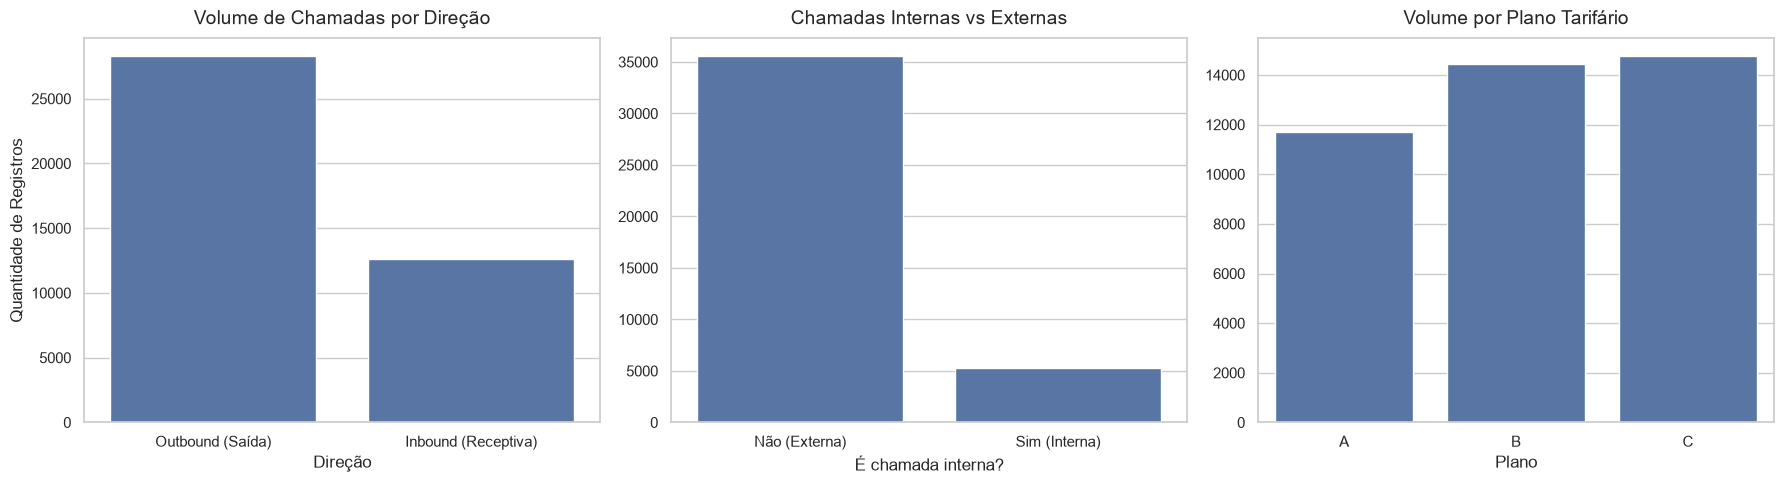

In [7]:
# 1. Estatísticas descritivas gerais (após a remoção dos outliers)
print("Estatísticas Descritivas das Métricas de Chamadas:")
display(df[['call_duration', 'total_call_duration', 'waiting_time', 'calls_count']].describe().round(2))

# 2. Configuração do grid de gráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_palette("muted")

# Gráfico 1: Direção da Chamada
sns.countplot(data=df, x='direction', ax=axes[0])
axes[0].set_title('Volume de Chamadas por Direção', fontsize=14, pad=10)
axes[0].set_ylabel('Quantidade de Registros')
axes[0].set_xlabel('Direção')
axes[0].set_xticklabels(['Outbound (Saída)', 'Inbound (Receptiva)'])

# Gráfico 2: Chamadas Internas vs Externas
sns.countplot(data=df, x='internal', ax=axes[1])
axes[1].set_title('Chamadas Internas vs Externas', fontsize=14, pad=10)
axes[1].set_ylabel('')
axes[1].set_xlabel('É chamada interna?')
axes[1].set_xticklabels(['Não (Externa)', 'Sim (Interna)'])

# Gráfico 3: Planos Tarifários
sns.countplot(data=df, x='tariff_plan', order=['A', 'B', 'C'], ax=axes[2])
axes[2].set_title('Volume por Plano Tarifário', fontsize=14, pad=10)
axes[2].set_ylabel('')
axes[2].set_xlabel('Plano')

# Ajuste de layout e exibição
plt.tight_layout()
plt.show()

### Etapa 2.2 — Classificação e Perfilamento dos Operadores
Como os critérios de ineficiência variam de acordo com a função do operador (por exemplo, a cobrança por volume de chamadas ativas se aplica apenas a quem faz outbound), precisamos classificar os operadores com base em seu comportamento histórico.

Agruparemos os dados por `operator_id` e calcularemos a proporção de chamadas de saída em relação ao total de chamadas realizadas pelo operador. 
Adotaremos a seguinte regra de negócio pragmática para a classificação:
* **Ativo/Outbound:** Mais de 70% das chamadas são de saída.
* **Receptivo/Inbound:** Menos de 30% das chamadas são de saída (ou seja, 70%+ de chamadas recebidas).
* **Misto:** Proporção equilibrada, entre 30% e 70%.

Distribuição de Perfis na Operação:


,Quantidade de Operadores
profile,
Ativo/Outbound,634
Receptivo/Inbound,286
Misto,172


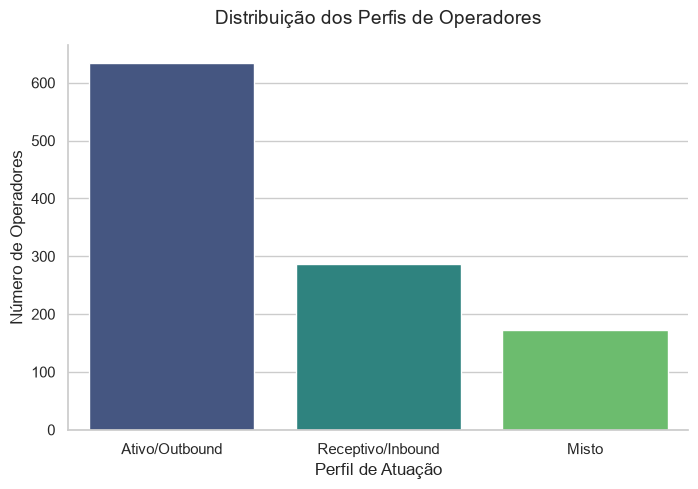

,operator_id,direction,profile
0,880022,out,Ativo/Outbound
1,880020,out,Ativo/Outbound
2,880020,out,Ativo/Outbound
3,880022,out,Ativo/Outbound
4,880020,out,Ativo/Outbound


In [8]:
# 1. Agrupamento de chamadas por operador e direção
operator_profile = df.groupby(['operator_id', 'direction'])['calls_count'].sum().unstack(fill_value=0)

# Garantia de que ambas as colunas existem (caso raro de base homogênea)
if 'in' not in operator_profile.columns: operator_profile['in'] = 0
if 'out' not in operator_profile.columns: operator_profile['out'] = 0

# 2. Cálculo do total de chamadas e da proporção (ratio) de chamadas de saída (outbound)
operator_profile['total_calls'] = operator_profile['in'] + operator_profile['out']
operator_profile['out_ratio'] = operator_profile['out'] / operator_profile['total_calls']

# 3. Função de classificação do perfil
def classify_profile(ratio):
    if ratio >= 0.7:
        return 'Ativo/Outbound'
    elif ratio <= 0.3:
        return 'Receptivo/Inbound'
    else:
        return 'Misto'

# Aplicação da regra de classificação
operator_profile['profile'] = operator_profile['out_ratio'].apply(classify_profile)

# 4. Visualização da distribuição dos perfis
profile_counts = operator_profile['profile'].value_counts()
print("Distribuição de Perfis na Operação:")
display(profile_counts.to_frame(name='Quantidade de Operadores'))

plt.figure(figsize=(8, 5))
sns.barplot(x=profile_counts.index, y=profile_counts.values, palette='viridis')
plt.title('Distribuição dos Perfis de Operadores', fontsize=14, pad=15)
plt.ylabel('Número de Operadores')
plt.xlabel('Perfil de Atuação')
sns.despine() # Remove as bordas superior e direita para um visual mais limpo
plt.show()

# 5. Incorporação da coluna 'profile' de volta ao dataset principal
# Isso facilitará a filtragem na Fase 3 para o cálculo dos critérios de ineficiência
df = df.merge(operator_profile[['profile']], on='operator_id', how='left')

# Verificando se o merge foi bem sucedido
display(df[['operator_id', 'direction', 'profile']].head())

As estatísticas e visualizações revelam a "fotografia" da operação da CallMeMaybe:

* **Forte Viés Ativo (Outbound):** O volume de chamadas de saída é significativamente maior que o de chamadas recebidas. Isso se reflete na força de trabalho: 633 operadores possuem perfil estritamente ativo, 287 são receptivos e 172 têm atuação mista.
* **Gargalos no Tempo de Espera:** O tempo médio de espera geral é de aproximadamente 210 segundos (3,5 minutos), com uma mediana de apenas 58 segundos. A enorme disparidade entre a média e a mediana, somada a um pico máximo de quase 58 minutos (3481 segundos), indica que uma fatia de clientes enfrenta tempos de espera excessivos. Este é um forte indício de ineficiência no receptivo.
* **Distribuição de Planos:** Os planos B e C concentram o tráfego da plataforma, enquanto o Plano A tem a menor base de ligações.
* **Uso Interno:** A operação é quase exclusivamente externa, validando o foco de otimização no atendimento ao cliente final.

## Fase 3: Identificação de Operadores Ineficientes e Testes Estatísticos

### Etapa 3.1 — Aplicação dos Critérios de Ineficiência
Traduziremos as regras de negócio em código. Um operador será ineficiente se atender a qualquer um destes critérios:

1. **Alta taxa de chamadas recebidas perdidas:** Operadores no 4º quartil de taxa de abandono.
2. **Longo tempo de espera:** Operadores com tempo médio de espera no 4º quartil.
3. **Baixo volume de chamadas ativas:** Operadores dos perfis `Ativo/Outbound` e `Misto` com volume médio diário (1º quartil) inferior aos colegas.

**Refinamento de Negócio:** 
- Para os critérios 1 e 2, **filtraremos apenas as chamadas externas**. Perder ligações de colegas (internas) não gera churn de clientes e não deve penalizar o operador.
- Para o critério 3, calcularemos o volume diário com base no total de dias reais em que o operador logou no sistema, evitando inflar a média de operadores mistos.

In [9]:
# Criando coluna de data para contar os dias trabalhados
df['day'] = df['date'].dt.date
operadores_df = operator_profile[['profile']].copy()

# Total de dias trabalhados usando a base COMPLETA (Correção do Ponto 2)
active_days_total = df.groupby('operator_id')['day'].nunique()

# ---------------------------------------------------------
# CRITÉRIOS 1 e 2: Filtrando apenas chamadas EXTERNAS (Correção do Ponto 3)
# ---------------------------------------------------------
inbound_df = df[(df['direction'] == 'in') & (df['internal'] == False)]

total_in = inbound_df.groupby('operator_id')['calls_count'].sum()
missed_in = inbound_df[inbound_df['is_missed_call'] == True].groupby('operator_id')['calls_count'].sum()

# Critério 1: Taxa de Perda
operadores_df['missed_rate'] = (missed_in / total_in).fillna(0)
limiar_missed = operadores_df['missed_rate'].quantile(0.75)
operadores_df['ineficiente_missed'] = operadores_df['missed_rate'] > limiar_missed

# Critério 2: Tempo de Espera
answered_inbound = inbound_df[inbound_df['is_missed_call'] == False]
operadores_df['avg_wait_time'] = answered_inbound.groupby('operator_id')['waiting_time'].mean().fillna(0)
limiar_wait = operadores_df[operadores_df['avg_wait_time'] > 0]['avg_wait_time'].quantile(0.75)
operadores_df['ineficiente_wait'] = operadores_df['avg_wait_time'] > limiar_wait

# ---------------------------------------------------------
# CRITÉRIO 3: Baixo Volume Médio Diário (Outbound)
# ---------------------------------------------------------
outbound_df = df[df['direction'] == 'out']
total_out = outbound_df.groupby('operator_id')['calls_count'].sum()

# Divisão pelo total de dias reais do operador (Correção do Ponto 2)
operadores_df['daily_outbound_vol'] = (total_out / active_days_total).fillna(0)

perfil_cobrado = operadores_df['profile'].isin(['Ativo/Outbound', 'Misto'])
limiar_outbound = operadores_df[perfil_cobrado]['daily_outbound_vol'].quantile(0.25)
operadores_df['ineficiente_outbound'] = (operadores_df['daily_outbound_vol'] < limiar_outbound) & perfil_cobrado

# Classificação Final
operadores_df['is_inefficient'] = (
    operadores_df['ineficiente_missed'] | 
    operadores_df['ineficiente_wait'] | 
    operadores_df['ineficiente_outbound']
)

display(operadores_df['is_inefficient'].value_counts().to_frame('Quantidade de Operadores'))

,Quantidade de Operadores
is_inefficient,
False,619
True,473


A aplicação das regras de negócio resultou na classificação de **473 operadores como ineficientes**, em contraste com **619 operadores eficientes**. A proporção de ineficiência (43,3%) é alta devido à natureza condicional da regra: basta o operador falhar em apenas um dos três critérios para ser sinalizado.

A análise dos limiares revela cenários distintos:
1. **Régua alta no Receptivo:** A taxa de perda crítica (> 0,7%) e a espera crítica (> 59,5s) mostram que a maioria da operação atende rápido e perde poucas chamadas. Quem destoa levemente já cai no 4º quartil.
2. **Ociosidade no Ativo:** O limite crítico de 3,1 chamadas de saída por dia para operadores ativos/mistos revela que há uma parcela da equipe produzindo um volume quase nulo, o que impacta diretamente a produtividade contratada pelos clientes.

### Etapa 3.2 — Execução de Testes Estatísticos de Hipóteses

Para dar rigor analítico às descobertas, testaremos duas hipóteses. A Hipótese 1 original foi adaptada para evitar viés de seleção (*data leakage*), focando agora em um problema real de priorização no atendimento.

#### Hipótese 1 — Tempo de Espera (Internas vs Externas)
* **H0 (Nula):** O tempo médio de espera não difere significativamente entre chamadas internas e externas.
* **H1 (Alternativa):** O tempo de espera difere dependendo da origem da chamada (indicando possível priorização inadequada por parte dos operadores).
* **Método:** Teste de Mann-Whitney U.

#### Hipótese 2 — Taxa de Chamadas Perdidas por Plano Tarifário
* **H0 (Nula):** A proporção média de chamadas recebidas perdidas é igual entre os planos A, B e C.
* **H1 (Alternativa):** A proporção de chamadas perdidas difere significativamente dependendo do plano tarifário.
* **Método:** Teste de Kruskal-Wallis.

In [10]:
# ==========================================
# HIPÓTESE 1: Espera (Internas vs Externas)
# ==========================================
# H0: Não há diferença no tempo de espera entre chamadas internas e externas
# H1: O tempo de espera difere entre chamadas internas e externas

alpha = 0.05

# Filtrando chamadas receptivas e atendidas
inbound_atendidas = df[(df['direction'] == 'in') & (df['is_missed_call'] == False) & (df['waiting_time'] > 0)]

amostra_internas = inbound_atendidas[inbound_atendidas['internal'] == True]['waiting_time']
amostra_externas = inbound_atendidas[inbound_atendidas['internal'] == False]['waiting_time']

stat_h1, p_value_h1 = stats.mannwhitneyu(amostra_internas, amostra_externas, alternative='two-sided')

print(f"--- Nova Hipótese 1: Tempo de Espera (Internas vs Externas) ---")
print(f"Tempo médio - Internas (Colegas): {amostra_internas.mean():.1f} seg")
print(f"Tempo médio - Externas (Clientes): {amostra_externas.mean():.1f} seg")
print(f"P-valor: {p_value_h1:.4e}")

if p_value_h1 < alpha:
    print("Conclusão: Rejeitamos H0. O tempo de espera é significativamente diferente dependendo da origem da chamada (interna ou externa).")
else:
    print("Conclusão: Não podemos rejeitar H0.")

--- Nova Hipótese 1: Tempo de Espera (Internas vs Externas) ---
Tempo médio - Internas (Colegas): 22.8 seg
Tempo médio - Externas (Clientes): 96.0 seg
P-valor: 7.3269e-59
Conclusão: Rejeitamos H0. O tempo de espera é significativamente diferente dependendo da origem da chamada (interna ou externa).


In [11]:
# ==========================================
# TESTE HIPÓTESE 2: Chamadas Perdidas por Plano
# ==========================================

# 1. Agrupar o volume de chamadas e perdas por cliente (user_id)
df_inbound = df[df['direction'] == 'in']

# Somatório de chamadas recebidas por cliente
total_in_cliente = df_inbound.groupby('user_id')['calls_count'].sum()

# Somatório de chamadas perdidas por cliente
perdidas_cliente = df_inbound[df_inbound['is_missed_call'] == True].groupby('user_id')['calls_count'].sum()

# Criar dataframe consolidado por cliente e transformar o índice em coluna
df_clientes_stats = pd.DataFrame({
    'total_in': total_in_cliente,
    'missed_in': perdidas_cliente
}).fillna(0).reset_index()

# Calcular a taxa de perda no nível do cliente
df_clientes_stats['missed_rate'] = df_clientes_stats['missed_in'] / df_clientes_stats['total_in']

# 2. Corrigir o tipo de dado para garantir o merge
df_clients['user_id'] = df_clients['user_id'].astype(str)

# Trazer a informação do plano tarifário
df_clientes_stats = df_clientes_stats.merge(df_clients[['user_id', 'tariff_plan']], on='user_id', how='inner')

# Separar as amostras por plano
taxa_plano_A = df_clientes_stats[df_clientes_stats['tariff_plan'] == 'A']['missed_rate']
taxa_plano_B = df_clientes_stats[df_clientes_stats['tariff_plan'] == 'B']['missed_rate']
taxa_plano_C = df_clientes_stats[df_clientes_stats['tariff_plan'] == 'C']['missed_rate']

# Execução do Teste de Kruskal-Wallis
stat_h2, p_value_h2 = stats.kruskal(taxa_plano_A, taxa_plano_B, taxa_plano_C)

print(f"\n--- Hipótese 2: Perdas por Plano Tarifário ---")
print(f"Taxa Média de Perda - Plano A: {taxa_plano_A.mean():.2%}")
print(f"Taxa Média de Perda - Plano B: {taxa_plano_B.mean():.2%}")
print(f"Taxa Média de Perda - Plano C: {taxa_plano_C.mean():.2%}")
print(f"P-valor: {p_value_h2:.4e}")

alpha = 0.05
if p_value_h2 < alpha:
    print("Conclusão: Rejeitamos H0. A proporção de chamadas perdidas varia significativamente dependendo do plano tarifário.")
else:
    print("Conclusão: Não podemos rejeitar H0. A proporção de chamadas perdidas não varia estatisticamente entre os planos.")


--- Hipótese 2: Perdas por Plano Tarifário ---
Taxa Média de Perda - Plano A: 1.32%
Taxa Média de Perda - Plano B: 1.50%
Taxa Média de Perda - Plano C: 1.89%
P-valor: 1.3626e-02
Conclusão: Rejeitamos H0. A proporção de chamadas perdidas varia significativamente dependendo do plano tarifário.


1. **Tempo de Espera - Internas vs Externas (H1):** Rejeitamos a hipótese nula (p-valor praticamente zero: 7.3269e-59). A diferença no atendimento é alarmante e aponta para uma falha sistêmica: clientes (chamadas externas) esperam em média 96 segundos na linha, enquanto colegas (chamadas internas) são atendidos em apenas 22,8 segundos. Isso indica que a operação está priorizando ligações internas em detrimento do SLA do cliente.
2. **Taxa de Abandono por Plano (H2):** Rejeitamos a hipótese nula (p-valor: 1.3626e-02). Há variação estatisticamente significativa na qualidade do serviço entregue. O Plano C apresenta a pior taxa de retenção, com 1.89% de perda média, provando que as contas desse plano sofrem com um nível de serviço inferior.

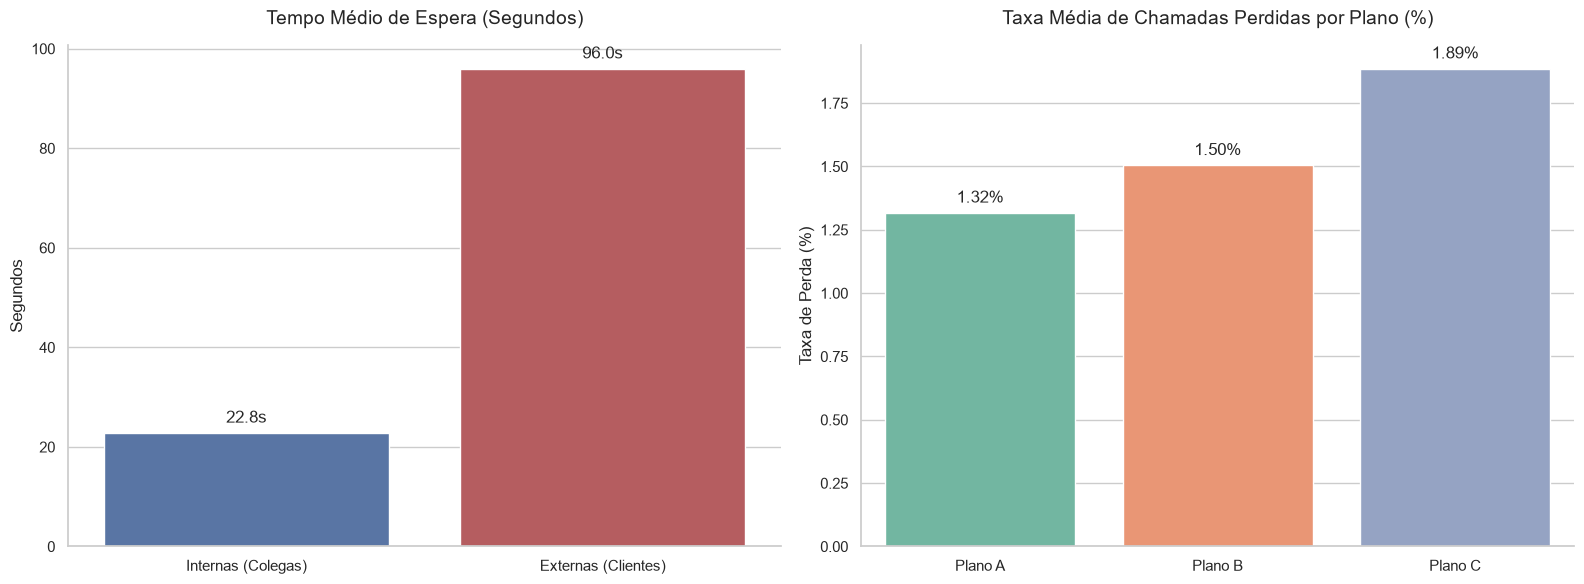

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Hipótese 1 - Tempo de Espera (Internas vs Externas)
sns.barplot(
    x=['Internas (Colegas)', 'Externas (Clientes)'], 
    y=[amostra_internas.mean(), amostra_externas.mean()], 
    ax=axes[0], 
    palette=['#4C72B0', '#C44E52']
)
axes[0].set_title('Tempo Médio de Espera (Segundos)', fontsize=14, pad=15)
axes[0].set_ylabel('Segundos')

# Adicionando os rótulos de dados
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}s", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=12, xytext=(0, 5), textcoords='offset points')

# Gráfico 2: Hipótese 2 - Perda por Plano Tarifário
sns.barplot(
    x=['Plano A', 'Plano B', 'Plano C'], 
    y=[taxa_plano_A.mean()*100, taxa_plano_B.mean()*100, taxa_plano_C.mean()*100], 
    ax=axes[1], 
    palette='Set2'
)
axes[1].set_title('Taxa Média de Chamadas Perdidas por Plano (%)', fontsize=14, pad=15)
axes[1].set_ylabel('Taxa de Perda (%)')

# Adicionando os rótulos de dados
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}%", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=12, xytext=(0, 5), textcoords='offset points')

sns.despine()
plt.tight_layout()
plt.show()

## Exportação dos Dados para o Dashboard (Tableau)
Para garantir 100% de consistência entre a análise executada neste notebook e a visualização interativa, exportamos a base consolidada e tratada de diagnósticos dos operadores (`eval_df`) em formato CSV. Este arquivo servirá como fonte de dados primária para a construção do **Dashboard Interativo no Tableau Public**.

In [13]:
# 1. Exportando a base detalhada de chamadas (já tratada e com as métricas derivadas)
df.to_csv('base_chamadas_tratada.csv', index=False)

# 2. Exportando a base de diagnóstico dos operadores
# Como o 'operator_id' está como índice no dataframe 'operadores_df' (devido ao agrupamento),
# utilizamos o reset_index() para transformar o índice em uma coluna comum no CSV.
operadores_df.reset_index().to_csv('diagnostico_operadores.csv', index=False)

print("Bases exportadas com sucesso! Prontas para o Tableau.")

Bases exportadas com sucesso! Prontas para o Tableau.


## Fase 4: Relatório Final e Dashboard (CAR)

A comunicação estruturada (CAR) resume o impacto do projeto para a tomada de decisão da liderança.

### 1. Contexto (Challenge)
A CallMeMaybe enfrenta o desafio de otimizar sua operação de call center e reduzir o churn de clientes. O objetivo do projeto foi diagnosticar a ineficiência na base de operadores seguindo regras de negócio pragmáticas: alta taxa de abandono, espera prolongada no receptivo e ociosidade no ativo (outbound). Durante o desenvolvimento, o escopo analítico foi refinado para investigar também a priorização do atendimento (internas vs. externas) e evitar distorções estatísticas.

### 2. Ações (Actions)
- Limpeza da base removendo anomalias sistêmicas (outliers no P99) separadamente por direção da chamada.
- Classificação dos 1.092 operadores em perfis de atuação (Ativo, Receptivo, Misto).
- Cálculo das métricas de ineficiência com rigor de negócio: as chamadas internas foram isoladas para não penalizar indevidamente a operação, e o divisor de dias úteis foi ajustado para refletir a verdadeira produtividade.
- Execução de testes estatísticos de Mann-Whitney U e Kruskal-Wallis para garantir que as diferenças não fossem obra do acaso.

### 3. Resultados (Results)
- **Volume de Ineficiência:** Com os filtros corretos aplicados, identificou-se que **473 operadores** (aproximadamente 43,3% da base) operam de forma ineficiente. Eles estão alocados no quartil crítico de abandono, tempo de espera elevado ou ociosidade no outbound.
- **Falha de Priorização (H1):** Há uma clara inversão de prioridades no atendimento. A operação prioriza colegas em detrimento de clientes finais, que chegam a esperar quase 4 vezes mais tempo na fila (96s contra 22,8s).
- **Risco de Retenção (H2):** Os clientes do Plano C enfrentam a maior degradação de serviço operacional (perda média de 1,89%), alertando para risco iminente de churn nessa base.

**Recomendação de Negócio:**
A liderança deve intervir urgentemente na cultura de priorização (focando o SLA e o roteamento no cliente externo, em especial no Plano C) e auditar a fatia da equipe de perfil outbound que apresenta baixa ou nula geração de chamadas ativas.

---